In [33]:
import numpy as np
import rioxarray as rio
import geopandas as gpd

In [34]:
red = rio.open_rasterio(r"C:\Users\thewe\Downloads\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B4.TIF").rio.reproject("EPSG:4326")
nir = rio.open_rasterio(r"C:\Users\thewe\Downloads\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B5.TIF").rio.reproject("EPSG:4326")
city_limits = gpd.read_file(r"C:\Users\thewe\Downloads\Boundary_City_Huntsville_poly\Boundary_City_Huntsville_poly.shp").to_crs("EPSG:4326")

In [35]:
# This correction came from ChatGPT
red = red * 0.0000275 - 0.2
nir = nir * 0.0000275 - 0.2

In [36]:
red = red.where((red > 0) & (red < 1))
nir = nir.where((nir > 0) & (nir < 1))

In [37]:
ndvi = (nir - red)/(nir + red)

In [38]:
ndvi.rio.write_crs("EPSG:4326")

<xarray.DataArray (band: 1, y: 7109, x: 8519)> Size: 484MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 7109, 8519))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 57kB 35.67 35.67 35.67 35.67 ... 33.54 33.54 33.54
  * x            (x) float64 68kB -88.71 -88.71 -88.71 ... -86.16 -86.16 -86.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

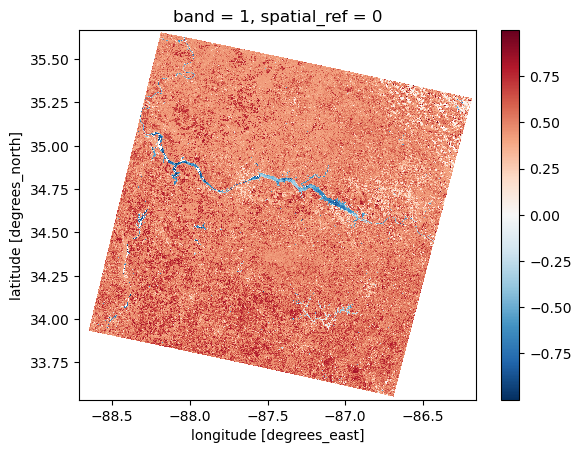

In [39]:
ndvi.plot()

In [40]:
ndvi_clip = ndvi.rio.clip(geometries=city_limits.geometry)

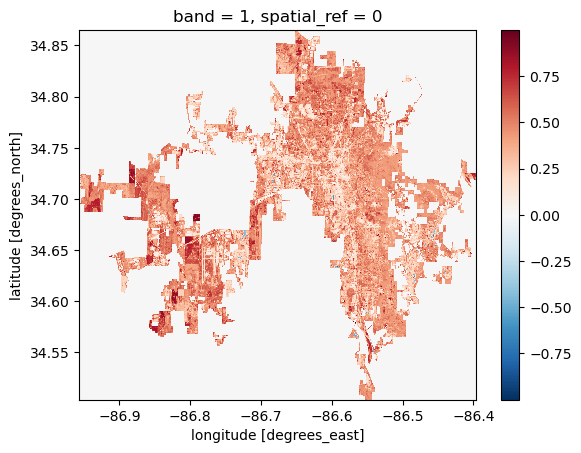

In [41]:
ndvi_clip.plot()

In [42]:
ndvi_clip.mean().values

array(0.11816201)